##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** The Secret Weapons

**Student names & numbers:**
* Sidney Felius - [Student no.]
* Scott Mulder - [Student no.]
* Valentijn Gruntsen - [Student no.]


---

## 0. Iteration setup

**Import libraries**

In [32]:
# CODE CELL: import the necessary libraries for this iteration

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


**Load dataset(s)**

In [33]:
# CODE CELL: import the necessary dataset(s) for this iteration
df = pd.read_csv('data/ships_inventory_iter1.csv')
df.head(5)

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the Nebula Brokerage pricing problem. Why is their current "gut feeling" approach a risk?.*

De prijzen worden momenteel bepaald op basis van een gut feeling. Dit leidt tot twee grote fouten:

Underpricing: Waardevolle schepen worden te goedkoop verkocht dit leidt tot winstderving.

Overpricing: Veelvoorkomende schepen worden te duur aangeboden dit leidt tot lange verkooptijd en zorgt ervoor dat er veel in voorraad staat vast.


**Business objective(s)**
*Justify why a data-driven baseline is needed*
Waarom is een baseline belangrijk?

Risicobeperking:
*Een onderbouwde prijs minimaliseert de gemiddelde afwijking tussen geschatte en werkelijke verkoopprijs.*

Meetbaar startpunt:
*Voordat andere complexere modellen worden gebouwd, moet eerst een eenvoudige benchmark worden vastgesteld.*

Prestatievergelijking:
*Toekomstige modellen  kunnen alleen beoordeeld worden als ze beter presteren dan de baseline.*

Zonder baseline is het niet mogelijk om te meten of een geavanceerder model waarde toevoegt.

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

**Success criteria**

*Determine success criteria for this iteration (the benchmark)*

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [34]:

# Display first 5 rows
print("First 5 Rows of the Dataset:")
display(df.head())

# Show dataset information (data types, non-null counts)
print("\nDataset Information:")
df.info()

# Show summary statistics for numerical columns
print("\nSummary Statistics (Numerical Columns):")
display(df.describe())

# Show summary statistics for categorical columns
print("\nSummary Statistics (Categorical Columns):")
display(df.describe(include=['object']))

First 5 Rows of the Dataset:


,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  str    
 4   Sector             368814 non-null  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 14.1 MB

Summary Statistics (Numerical Columns):


,Ship_ID,Galactic_Credits,Model_Cycle
count,3.688140e+05,368814.000000,361408.000000
mean,7.311485e+09,19453.536818,7511.264529
std,4.381124e+06,15540.472943,9.078571
min,7.301583e+09,501.000000,7400.000000
25%,7.308105e+09,7950.000000,7508.000000
50%,7.312604e+09,15990.000000,7513.000000
75%,7.315245e+09,27990.000000,7517.000000
max,7.317101e+09,777777.000000,7522.000000



Summary Statistics (Categorical Columns):


C:\Users\sidne\AppData\Local\Temp\ipykernel_29056\2993480461.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object']))


,Ship_Manufacturer,Sector
count,368814,368814
unique,28,51
top,Independent Shipwrights,Calodan Expanse
freq,94444,42150


**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

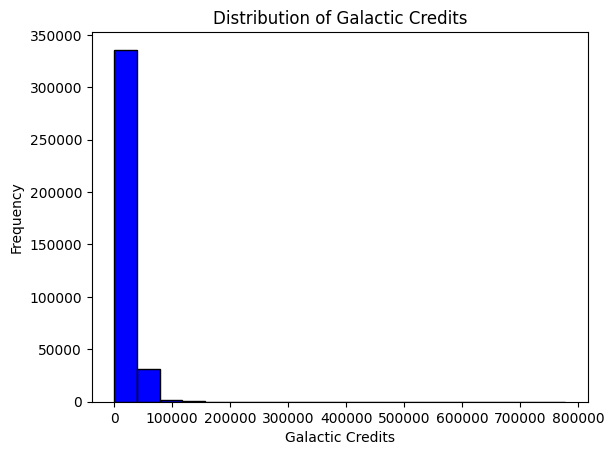

In [35]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)
plt.hist(df['Galactic_Credits'].dropna(), bins=20, color='blue', edgecolor='black')
plt.title('Distribution of Galactic Credits') 
plt.xlabel('Galactic Credits')
plt.ylabel('Frequency')
plt.show()



**Data insights and data quality**
* **Insights:** What are the key trends? What does the distribution look like? What does that mean? 
* **Quality issues:** Document missing values, duplicates, outliers, etc.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [36]:
# CODE CELL: Data cleaning and preprocessing steps

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [37]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

In [38]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [39]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*What is the difference between the metrics? What does this mean? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What did you learn? What are the limitations of this current model?*

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |